In [6]:
import requests
import pandas as pd
from datetime import timedelta, datetime

In [31]:
def load_carbon_intensity_data(start_date: str, end_date: str) -> pd.DataFrame:
    """
    Load Carbon Intensity API data for any specified date range.
    Handles the API 31-day limit by fetching data in chunks.
    """

    start = pd.to_datetime(start_date)
    end = pd.to_datetime(end_date)

    if start >= end:
        raise ValueError("end_date must be after start_date")

    dfs = []
    current = start

    while current < end:
        next_date = min(current + timedelta(days=30), end)

        url = (
            f"https://api.carbonintensity.org.uk/intensity/"
            f"{current.strftime('%Y-%m-%d')}/{next_date.strftime('%Y-%m-%d')}"
        )

        response = requests.get(url, timeout=30)
        response.raise_for_status()

        try:
            payload = response.json()
        except ValueError:
            print(f"Warning: Carbon API returned non-JSON response for {current} - {next_date}")
            payload = {}

        data = payload.get("data", []) if isinstance(payload, dict) else []

        if data:
            dfs.append(pd.json_normalize(data))

        current = next_date

    if not dfs:
        return pd.DataFrame()

    return pd.concat(dfs, ignore_index=True)

In [3]:
df = load_carbon_intensity_data('2023-01-01','2023-02-01')
df

,from,to,intensity.forecast,intensity.actual,intensity.index
0,2022-12-31T23:30Z,2023-01-01T00:00Z,75,65.0,low
1,2023-01-01T00:00Z,2023-01-01T00:30Z,73,72.0,low
2,2023-01-01T00:30Z,2023-01-01T01:00Z,63,80.0,low
3,2023-01-01T01:00Z,2023-01-01T01:30Z,71,72.0,low
4,2023-01-01T01:30Z,2023-01-01T02:00Z,76,65.0,low
...,...,...,...,...,...
1485,2023-01-31T21:30Z,2023-01-31T22:00Z,127,96.0,low
1486,2023-01-31T22:00Z,2023-01-31T22:30Z,104,95.0,low
1487,2023-01-31T22:30Z,2023-01-31T23:00Z,84,81.0,low
1488,2023-01-31T23:00Z,2023-01-31T23:30Z,82,74.0,low


In [32]:
def preprocess_carbon_intensity_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Clean and preprocess Carbon Intensity API dataframe.
    """

    if df.empty:
        return pd.DataFrame(columns=["timestamp", "carbon_intensity_gCO2_kWh"])

    df = df.copy()

    df["timestamp"] = pd.to_datetime(df["from"], utc=True).dt.tz_convert(None)
    df = df.rename(columns={
        "intensity.actual": "carbon_intensity_gCO2_kWh",  # ← rename directly, skip intermediate
        "intensity.forecast": "forecast"
    })
    df["carbon_intensity_gCO2_kWh"] = pd.to_numeric(df["carbon_intensity_gCO2_kWh"], errors='coerce')
    df = df[["timestamp", "carbon_intensity_gCO2_kWh"]]

    df = (
        df
        .sort_values("timestamp")
        .drop_duplicates(subset="timestamp")
        .reset_index(drop=True)
    )

    return df

In [58]:
def preprocess_carbon_intensity_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Clean and preprocess Carbon Intensity API dataframe.
    """

    if df.empty:
        return pd.DataFrame(columns=["timestamp", "carbon_intensity_gCO2_kWh"])

    df = df.copy()

    df["timestamp"] = pd.to_datetime(df["from"], utc=True).dt.tz_convert(None)
    df = df.rename(columns={
        "intensity.actual": "actual",
        "intensity.forecast": "forecast"
    })
    df["carbon_intensity_gCO2_kWh"] = pd.to_numeric(df["actual"], errors='coerce')
    df["carbon_intensity_gCO2_kWh"] = df["carbon_intensity_gCO2_kWh"].fillna(
        pd.to_numeric(df["forecast"], errors='coerce')
    )
    df = df[["timestamp", "carbon_intensity_gCO2_kWh"]]

    df = (
        df
        .sort_values("timestamp")
        .drop_duplicates(subset="timestamp")
        .reset_index(drop=True)
    )

    return df


In [59]:
carbon_df = load_carbon_intensity_data('2017-09-12', '2017-12-30')
carbon_df = preprocess_carbon_intensity_data(carbon_df)
print(carbon_df.columns.tolist())
print(carbon_df.dtypes)
print(carbon_df.head(-10))

['timestamp', 'carbon_intensity_gCO2_kWh']
timestamp                    datetime64[ns]
carbon_intensity_gCO2_kWh             int64
dtype: object
               timestamp  carbon_intensity_gCO2_kWh
0    2017-09-11 23:30:00                        144
1    2017-09-12 00:00:00                        142
2    2017-09-12 00:30:00                        140
3    2017-09-12 01:00:00                        139
4    2017-09-12 01:30:00                        137
...                  ...                        ...
5218 2017-12-29 16:30:00                        289
5219 2017-12-29 17:00:00                        285
5220 2017-12-29 17:30:00                        286
5221 2017-12-29 18:00:00                        278
5222 2017-12-29 18:30:00                        282

[5223 rows x 2 columns]


In [51]:
def fetch_exelon(start_date, end_date):
    """
    fetch data within specifite dates from Exelon AGBT API and returns it as a pandas dataframe
    """
    url = "https://data.elexon.co.uk/bmrs/api/v1/generation/actual/per-type"

    start = datetime.strptime(start_date, "%Y-%m-%d")
    end = datetime.strptime(end_date, "%Y-%m-%d")

    dfs = []

    while start <= end:

        chunk_end = min(start + timedelta(days=6), end)

        params = {
            "from": start.strftime("%Y-%m-%d"),
            "to": chunk_end.strftime("%Y-%m-%d"),
            "settlementPeriodFrom": 1,
            "settlementPeriodTo": 50,
            "format": "json"
        }

        response = requests.get(url, params=params, timeout=30)
        response.raise_for_status()

        data = response.json().get("data", [])

        if data:
            df_raw = pd.DataFrame(data)
            df_exploded = df_raw.explode('data').reset_index(drop=True)
            df_normalized = pd.json_normalize(df_exploded['data'])
            df_normalized['startTime'] = df_exploded['startTime'].values
            dfs.append(df_normalized)

        start = chunk_end + timedelta(days=1)

    if not dfs:
        return pd.DataFrame(columns=["startTime", "psrType", "quantity"])

    return pd.concat(dfs, ignore_index=True)

In [52]:
exelon_df = fetch_exelon('2017-09-01', '2026-03-12')
exelon_df

,businessType,psrType,quantity,startTime
0,Production,Biomass,0.000,2017-08-31T23:00:00Z
1,Production,Fossil Gas,9448.000,2017-08-31T23:00:00Z
2,Production,Fossil Hard coal,1777.000,2017-08-31T23:00:00Z
3,Production,Fossil Oil,0.000,2017-08-31T23:00:00Z
4,Production,Hydro Pumped Storage,0.000,2017-08-31T23:00:00Z
...,...,...,...,...
1593004,Production,Nuclear,3205.000,2026-03-12T12:00:00Z
1593005,Production,Other,703.000,2026-03-12T12:00:00Z
1593006,Solar generation,Solar,2610.000,2026-03-12T12:00:00Z
1593007,Wind generation,Wind Offshore,11531.621,2026-03-12T12:00:00Z


In [25]:
def exelon_preproc(df):
    """
    preprocessing exelon dataframe:
    convert StartTime column from object into datetime, pivot PsrType (fuel type) column
    into their own columns with their individual generation quantities,
    """
    df['startTime'] = pd.to_datetime(df['startTime']).dt.tz_convert(None)
    df_pivot = df.pivot_table(
        index='startTime',
        columns='psrType',
        values='quantity',
        aggfunc='sum'
    )

    df_pivot['TotalOutput-MW'] = df_pivot.sum(axis=1)

    return df_pivot

In [53]:
# exelon_df = fetch_exelon('2017-09-12', '2026-03-12')
exelon_df = exelon_preproc(exelon_df)
print(exelon_df.columns.tolist())
print(exelon_df.dtypes)
print(exelon_df.head())

['Biomass', 'Fossil Gas', 'Fossil Hard coal', 'Fossil Oil', 'Hydro Pumped Storage', 'Hydro Run-of-river and poundage', 'Nuclear', 'Other', 'Solar', 'Wind Offshore', 'Wind Onshore', 'TotalOutput-MW']
psrType
Biomass                            float64
Fossil Gas                         float64
Fossil Hard coal                   float64
Fossil Oil                         float64
Hydro Pumped Storage               float64
Hydro Run-of-river and poundage    float64
Nuclear                            float64
Other                              float64
Solar                              float64
Wind Offshore                      float64
Wind Onshore                       float64
TotalOutput-MW                     float64
dtype: object
psrType              Biomass  Fossil Gas  Fossil Hard coal  Fossil Oil  \
startTime                                                                
2017-08-31 23:00:00      0.0      9448.0            1777.0         0.0   
2017-08-31 23:30:00      0.0      8828.0 

In [11]:
exelon_df.hist(figsize=(10,10))

NameError: name 'exelon_df' is not defined

In [55]:
exelon_df.apply(lambda x: x==0).sum()

psrType
Biomass                              7456
Fossil Gas                           4505
Fossil Hard coal                    78031
Fossil Oil                         144810
Hydro Pumped Storage                65319
Hydro Run-of-river and poundage      4505
Nuclear                              4505
Other                                4718
Solar                               62295
Wind Offshore                          73
Wind Onshore                           65
TotalOutput-MW                          0
dtype: int64

In [ ]:
# exelon_df = fetch_exelon('2023-01-01', '2023-02-01')
zero_times = exelon_df[(exelon_df['quantity'] == 0) & (exelon_df['psrType'] == 'Nuclear')]['startTime']
print(zero_times.shape())

In [29]:
zero_times = exelon_df[(exelon_df['quantity'] == 0) & (exelon_df['psrType'] == 'Nuclear')]['startTime']
print(zero_times.tail(10))
print(f"Total zero periods: {len(zero_times)}")
print(f"Last zero: {zero_times.max()}")
print(f"First non-zero: {exelon_df[(exelon_df['quantity'] != 0) & (exelon_df['psrType'] == 'Nuclear')]['startTime'].min()}")

5924    2023-01-12T06:00:00Z
5935    2023-01-12T06:30:00Z
5946    2023-01-12T07:00:00Z
5957    2023-01-12T07:30:00Z
5968    2023-01-12T08:00:00Z
5979    2023-01-12T08:30:00Z
5990    2023-01-12T09:00:00Z
6001    2023-01-12T09:30:00Z
6012    2023-01-12T10:00:00Z
6023    2023-01-12T10:30:00Z
Name: startTime, dtype: object
Total zero periods: 548
Last zero: 2023-01-12T10:30:00Z
First non-zero: 2023-01-12T11:00:00Z


what to do about data gaps in production like 2023:
impute?
delete - if so delete all rows? or just production rows?
currently showing as zero rather than as nulls
maybe go find where nuclear = zero - turn all production to NaN MASK/IMPUTE


In [30]:
def fetch_weather(start_date, end_date, latitude=51.5, longitude=-0.1):
    '''fetch api data from open-meteo archive,
    returns selected parameters hourly for London (based on long and lat).
    Dates in string format. See weather_data_notes.txt for information on selected params.'''

    url = 'https://archive-api.open-meteo.com/v1/archive'

    selected_params = {
        'latitude': latitude,
        'longitude': longitude,
        'start_date': start_date,
        'end_date': end_date,
        'timezone': 'UTC',
        'hourly': [
            'temperature_2m',
            'wind_speed_100m',
            'wind_gusts_10m',
            'cloud_cover',
            'shortwave_radiation',
            'direct_radiation',
            'diffuse_radiation',
            'pressure_msl',
            'snowfall',
            'rain',
            'precipitation'
        ]
    }

    response = requests.get(url, params=selected_params, timeout=30)
    response.raise_for_status()

    data = response.json()

    if "hourly" not in data:
        raise ValueError(f"Unexpected API response:{data}")

    df = pd.DataFrame(data["hourly"])

    return df

make a predictive energy thing that can beat the prediction of the grid

In [2]:
from google.cloud import bigquery
PROJECT = "gridzero-489711"
DATASET = "merged_set"
TABLE = "test_merge_2017_onward_raw"

query = f"""
    SELECT *
    FROM {PROJECT}.{DATASET}.{TABLE}
"""

client = bigquery.Client('gridzero-489711')
query_job = client.query(query)
result = query_job.result()
combined_data_df = result.to_dataframe()
combined_data_df.columns

/home/joseph/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Index(['datetime', 'temperature_2m_c', 'wind_speed_100m_ms',
       'wind_gusts_10m_ms', 'cloud_cover_pct', 'shortwave_radiation_wm2',
       'direct_radiation_wm2', 'diffuse_radiation_wm2', 'pressure_msl_hpa',
       'snowfall_cm', 'rain_mm', 'precipitation_mm', 'Biomass', 'Fossil Gas',
       'Fossil Hard coal', 'Fossil Oil', 'Hydro Pumped Storage',
       'Hydro Run-of-river and poundage', 'Nuclear', 'Other', 'Solar',
       'Wind Offshore', 'Wind Onshore', 'TotalOutput-MW',
       'carbon_intensity_gCO2_kWh', 'status'],
      dtype='object')

In [3]:
combined_data_df.shape

(148991, 26)

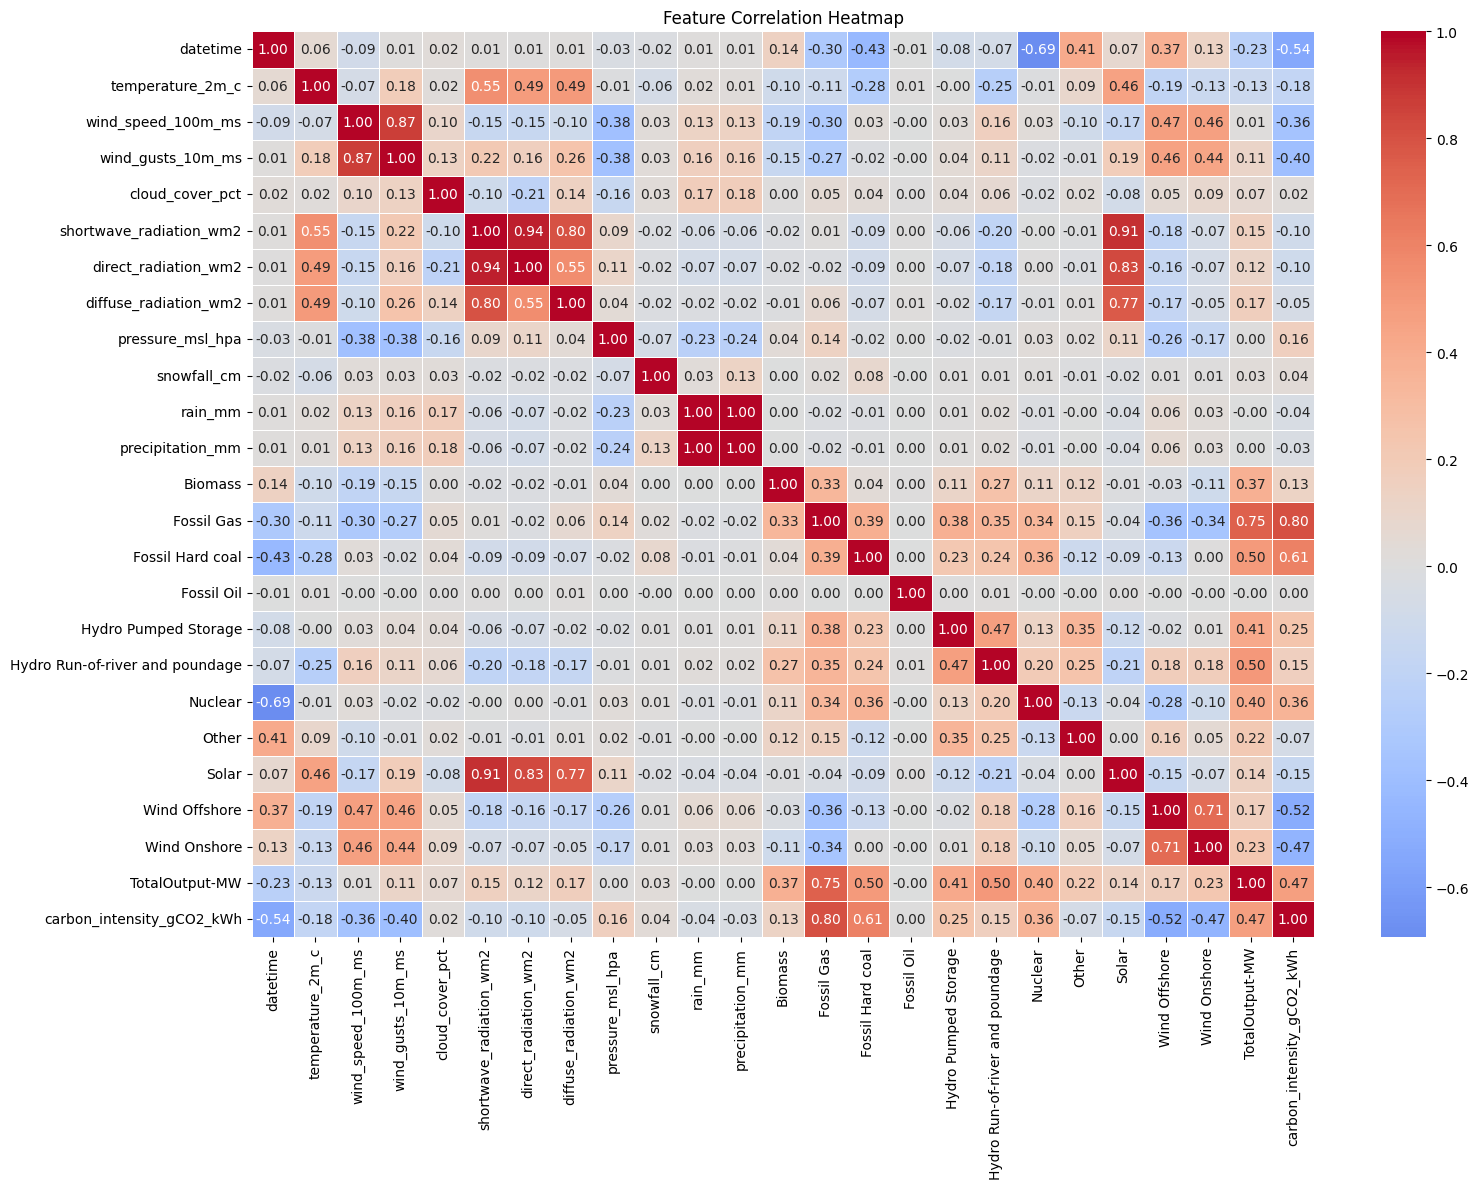

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Drop non-numeric columns for correlation
numeric_df = combined_data_df.drop(columns=['status'])

# Correlation heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

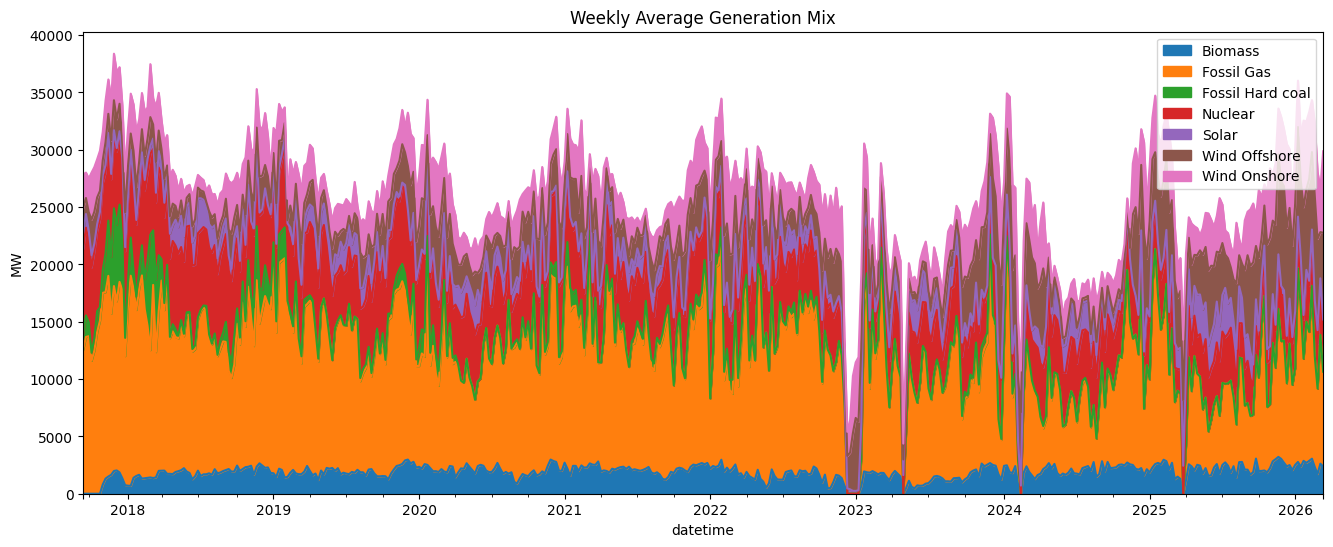

In [5]:
fuel_cols = ['Biomass', 'Fossil Gas', 'Fossil Hard coal', 'Nuclear',
             'Solar', 'Wind Offshore', 'Wind Onshore']
# combined_data_df[fuel_cols].resample('W').mean().plot(kind='area', stacked=True, figsize=(16, 6))
combined_data_df.set_index('datetime')[fuel_cols].resample('W').mean().plot(kind='area', stacked=True, figsize=(16, 6))
plt.title('Weekly Average Generation Mix')
plt.ylabel('MW')
plt.show()

/tmp/ipykernel_270127/2616266786.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  combined_data_df.set_index('datetime')[['carbon_intensity_gCO2_kWh', 'renewables']].resample('M').mean().plot(


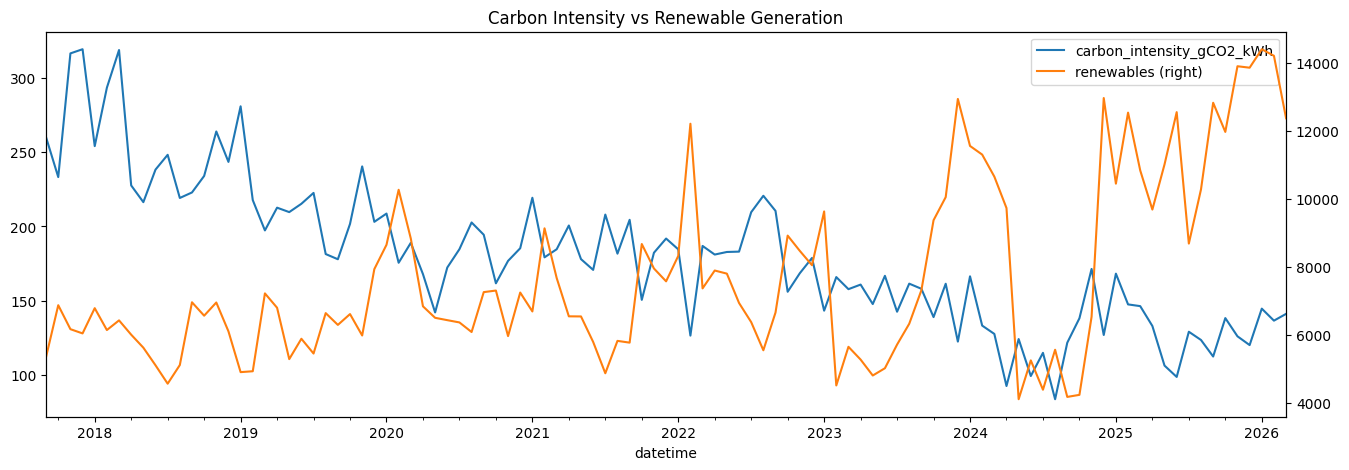

In [8]:
combined_data_df['renewables'] = combined_data_df['Solar'] + combined_data_df['Wind Offshore'] + combined_data_df['Wind Onshore']
combined_data_df.set_index('datetime')[['carbon_intensity_gCO2_kWh', 'renewables']].resample('M').mean().plot(
    secondary_y='renewables', figsize=(16, 5)
)
plt.title('Carbon Intensity vs Renewable Generation')
plt.show()

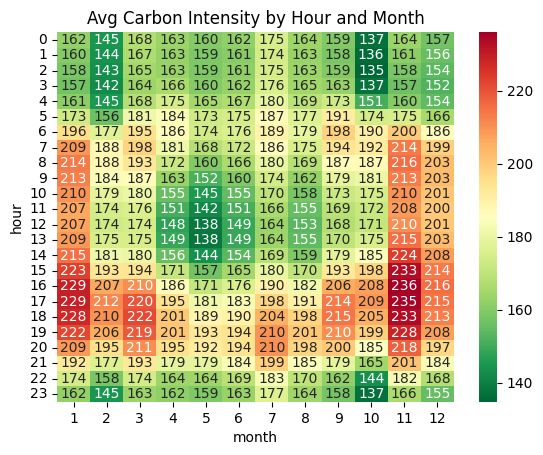

In [10]:
import pandas as pd
combined_data_df['hour'] = pd.to_datetime(combined_data_df['datetime']).dt.hour
combined_data_df['month'] = pd.to_datetime(combined_data_df['datetime']).dt.month

pivot = combined_data_df.pivot_table(
    values='carbon_intensity_gCO2_kWh',
    index='hour',
    columns='month',
    aggfunc='mean'
)

sns.heatmap(pivot, cmap='RdYlGn_r', annot=True, fmt='.0f')
plt.title('Avg Carbon Intensity by Hour and Month')
plt.show()

In [19]:
print("Non-zero:", (combined_data_df['Fossil Oil'] > 0).sum())

Non-zero: 9


/tmp/ipykernel_270127/1236099898.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = combined_data_df.set_index('datetime')[fuel_cols].resample('M').mean()


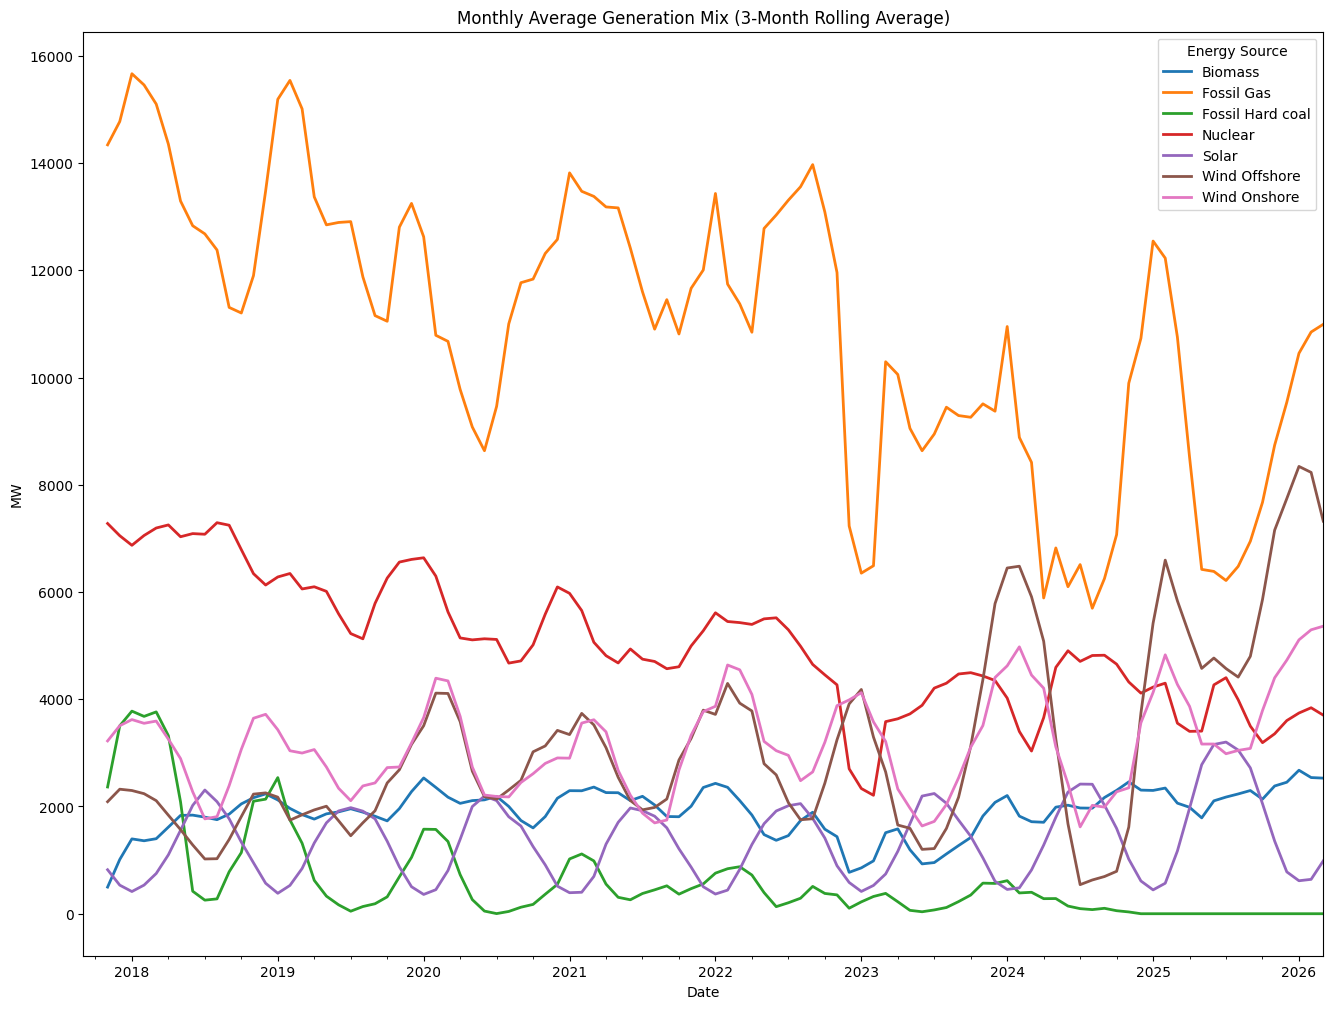

In [29]:
fuel_cols = ['Biomass', 'Fossil Gas', 'Fossil Hard coal', 'Nuclear',
             'Solar', 'Wind Offshore', 'Wind Onshore']

monthly = combined_data_df.set_index('datetime')[fuel_cols].resample('M').mean()

smoothed = monthly.rolling(3).mean()   # 3-month rolling average

smoothed.plot(
    kind='line',
    figsize=(16, 12),
    linewidth=2
)

plt.title('Monthly Average Generation Mix (3-Month Rolling Average)')
plt.ylabel('MW')
plt.xlabel('Date')
plt.legend(title='Energy Source')
plt.show()

/tmp/ipykernel_270127/1382563258.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = combined_data_df.set_index('datetime')[fuel_cols].resample('M').mean()


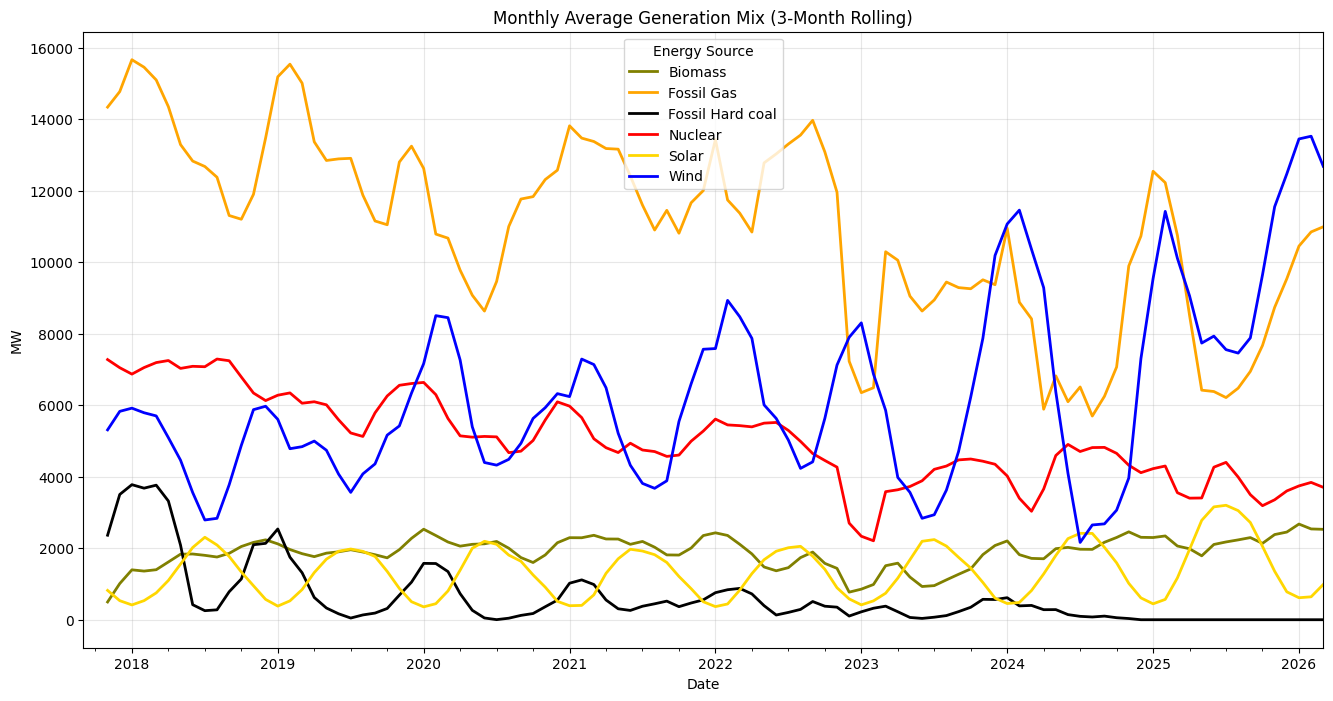

In [36]:
fuel_cols = ['Biomass', 'Fossil Gas', 'Fossil Hard coal', 'Nuclear',
             'Solar', 'Wind Offshore', 'Wind Onshore']

monthly = combined_data_df.set_index('datetime')[fuel_cols].resample('M').mean()

# Combine wind sources
monthly['Wind'] = monthly['Wind Offshore'] + monthly['Wind Onshore']

# Drop the original wind columns
monthly = monthly.drop(columns=['Wind Offshore', 'Wind Onshore'])

# Smooth data
smoothed = monthly.rolling(3).mean()

colors = {
    'Biomass': 'olive',
    'Fossil Gas': 'orange',
    'Fossil Hard coal': 'black',
    'Nuclear': 'red',
    'Solar': 'gold',
    'Wind': 'blue'
}

smoothed.plot(
    figsize=(16, 8),
    linewidth=2,
    color=[colors[col] for col in smoothed.columns]
)

plt.title('Monthly Average Generation Mix (3-Month Rolling)')
plt.ylabel('MW')
plt.xlabel('Date')
plt.grid(alpha=0.3)
plt.legend(title='Energy Source')

plt.show()

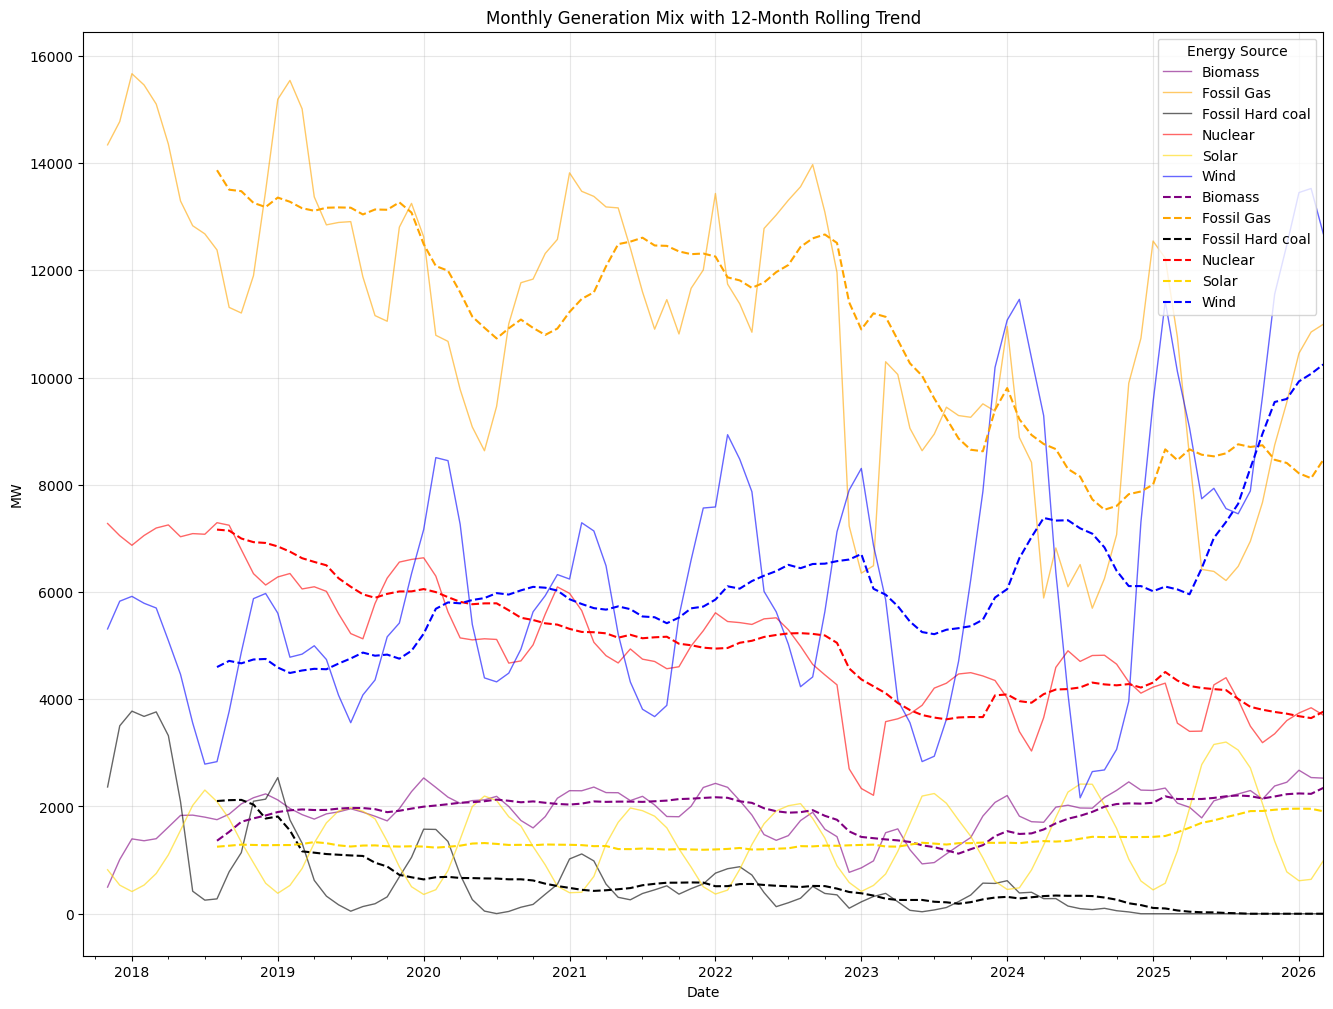

In [50]:
fuel_cols = ['Biomass', 'Fossil Gas', 'Fossil Hard coal', 'Nuclear',
             'Solar', 'Wind Offshore', 'Wind Onshore']

monthly = combined_data_df.set_index('datetime')[fuel_cols].resample('ME').mean()

# Combine wind
monthly['Wind'] = monthly['Wind Offshore'] + monthly['Wind Onshore']
monthly = monthly.drop(columns=['Wind Offshore', 'Wind Onshore'])

# Main lines (slightly smoothed)
smoothed = monthly.rolling(3).mean()

# Yearly rolling trend
yearly_trend = monthly.rolling(12).mean()

fig, ax = plt.subplots(figsize=(16,12))

colors = {
    'Biomass': 'purple',
    'Fossil Gas': 'orange',
    'Fossil Hard coal': 'black',
    'Nuclear': 'red',
    'Solar': 'gold',
    'Wind': 'blue'
}

# Plot main lines
smoothed.plot(ax=ax, linewidth=1, alpha=0.6,
              color=[colors[col] for col in smoothed.columns])

# Plot trendlines
yearly_trend.plot(
    ax=ax,
    linewidth=1.5,
    linestyle='--',
    color=[colors[col] for col in smoothed.columns]
)

plt.title('Monthly Generation Mix with 12-Month Rolling Trend')
plt.ylabel('MW')
plt.xlabel('Date')
plt.grid(alpha=0.3)
plt.legend(title='Energy Source')

plt.show()

In [64]:
combined_data_df.isna().sum()

temperature_2m_c                      0
wind_speed_100m_ms                    0
wind_gusts_10m_ms                     0
cloud_cover_pct                       0
shortwave_radiation_wm2               0
direct_radiation_wm2                  0
diffuse_radiation_wm2                 0
pressure_msl_hpa                      0
snowfall_cm                           0
rain_mm                               0
precipitation_mm                      0
Biomass                            4698
Fossil Gas                         4698
Fossil Hard coal                   4698
Fossil Oil                         4698
Hydro Pumped Storage               4698
Hydro Run-of-river and poundage    4698
Nuclear                            4698
Other                              4698
Solar                              4698
Wind Offshore                      4698
Wind Onshore                       4698
TotalOutput-MW                     4698
carbon_intensity_gCO2_kWh           226
renewables                         4698


ValueError: Input y contains NaN.

In [ ]:
from sklearn.impute import KNNImputer
def impute_values(df):
    df = df.copy()

    # 1. Check if 'datetime' is a column; if so, move it to index
    if 'datetime' in df.columns:
        df['datetime'] = pd.to_datetime(df['datetime'])
        df = df.set_index('datetime')

    # 2. Ensure the index is actually DatetimeIndex before extracting
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)

    # 3. Now extract your time features safely
    df['hour'] = df.index.hour
    df['month'] = df.index.month

    # Most sources
    linear_sources = ['Biomass', 'Fossil Gas', 'Nuclear', 'Other',
                    'Fossil Hard coal', 'Fossil Oil'
                        ]

    df[linear_sources] = df[linear_sources].interpolate(method='linear')
    #hydro sources to be moved out once precipitation becomes a feature

    # Weather-dependent
    solar_features = ['Solar', 'shortwave_radiation_wm2', 'direct_radiation_wm2',
                    'diffuse_radiation_wm2', 'temperature_2m_c', 'hour', 'month']

    wind_features = ['Wind Offshore', 'Wind Onshore',
                    'wind_speed_100m_ms', 'wind_gusts_10m_ms', 'hour', 'month']

    #FOR WHEN PRECIPITATION IS A FEATURE
    hydro_features = ['Hydro Pumped Storage', 'Hydro Run-of-river and poundage',
                      'month', 'Other', 'precipitation_mm']
    imputer = KNNImputer(n_neighbors=5)
    df[hydro_features] = imputer.fit_transform(df[hydro_features])


    for features in [solar_features, wind_features]:
        imputer = KNNImputer(n_neighbors=5)
        df[features] = imputer.fit_transform(df[features])

    # Recalculate TotalOutput and carbon_intensity from imputed values
    # rather than imputing them directly
    energy_cols = ['Biomass', 'Fossil Gas', 'Fossil Hard coal', 'Fossil Oil',
                'Hydro Pumped Storage', 'Hydro Run-of-river and poundage',
                'Nuclear', 'Other', 'Solar', 'Wind Offshore', 'Wind Onshore']
    df['TotalOutput-MW'] = df[energy_cols].sum(axis=1)

    return df

In [80]:
df_imputed = impute_values(combined_data_df)
df_imputed.tail()

,temperature_2m_c,wind_speed_100m_ms,wind_gusts_10m_ms,cloud_cover_pct,shortwave_radiation_wm2,direct_radiation_wm2,diffuse_radiation_wm2,pressure_msl_hpa,snowfall_cm,rain_mm,...,Nuclear,Other,Solar,Wind Offshore,Wind Onshore,TotalOutput-MW,carbon_intensity_gCO2_kWh,renewables,hour,month
1970-01-01 00:00:00.000148986,11.4,50.8,68.0,100,0.0,0.0,0.0,1004.1,0.0,0.0,...,3207.0,511.0,1.4,6639.9340,6446.8696,22845.2036,NaN,NaN,0.0,1.0
1970-01-01 00:00:00.000148987,11.4,50.8,68.0,100,0.0,0.0,0.0,1004.1,0.0,0.0,...,3207.0,511.0,1.4,6639.9340,6446.8696,22845.2036,NaN,NaN,0.0,1.0
1970-01-01 00:00:00.000148988,11.4,51.5,67.3,100,0.0,0.0,0.0,1003.0,0.0,0.1,...,3207.0,511.0,1.4,8027.3470,6810.1042,25016.4512,NaN,NaN,0.0,1.0
1970-01-01 00:00:00.000148989,11.4,51.5,67.3,100,0.0,0.0,0.0,1003.0,0.0,0.1,...,3207.0,511.0,1.4,8027.3470,6810.1042,25016.4512,NaN,NaN,0.0,1.0
1970-01-01 00:00:00.000148990,11.4,46.5,65.5,100,0.0,0.0,0.0,1001.6,0.0,0.1,...,3207.0,511.0,1.4,3182.1884,4575.4020,17936.5904,NaN,NaN,0.0,1.0


In [81]:
df_imputed.tail(20)

,temperature_2m_c,wind_speed_100m_ms,wind_gusts_10m_ms,cloud_cover_pct,shortwave_radiation_wm2,direct_radiation_wm2,diffuse_radiation_wm2,pressure_msl_hpa,snowfall_cm,rain_mm,...,Nuclear,Other,Solar,Wind Offshore,Wind Onshore,TotalOutput-MW,carbon_intensity_gCO2_kWh,renewables,hour,month
1970-01-01 00:00:00.000148971,11.0,45.0,72.7,100,170.0,13.0,157.0,1011.2,0.0,0.0,...,3207.0,511.0,1718.0,4461.0544,5421.3050,21357.3594,NaN,NaN,0.0,1.0
1970-01-01 00:00:00.000148972,11.1,45.0,83.5,100,141.0,17.0,124.0,1010.0,0.0,0.0,...,3207.0,511.0,1963.4,7761.1146,7532.0686,27013.5832,NaN,NaN,0.0,1.0
1970-01-01 00:00:00.000148973,11.1,45.0,83.5,100,141.0,17.0,124.0,1010.0,0.0,0.0,...,3207.0,511.0,1963.4,7761.1146,7532.0686,27013.5832,NaN,NaN,0.0,1.0
1970-01-01 00:00:00.000148974,11.1,46.6,68.0,100,94.0,3.0,91.0,1009.1,0.0,0.0,...,3207.0,511.0,1015.8,7274.9708,6353.8414,24401.6122,NaN,NaN,0.0,1.0
1970-01-01 00:00:00.000148975,11.1,46.6,68.0,100,94.0,3.0,91.0,1009.1,0.0,0.0,...,3207.0,511.0,1015.8,7274.9708,6353.8414,24401.6122,NaN,NaN,0.0,1.0
1970-01-01 00:00:00.000148976,11.4,51.4,70.6,100,45.0,1.0,44.0,1008.2,0.0,0.1,...,3207.0,511.0,790.6,10967.5730,9117.5938,31053.3668,NaN,NaN,0.0,1.0
1970-01-01 00:00:00.000148977,11.4,51.4,70.6,100,45.0,1.0,44.0,1008.2,0.0,0.1,...,3207.0,511.0,790.6,10967.5730,9117.5938,31053.3668,NaN,NaN,0.0,1.0
1970-01-01 00:00:00.000148978,11.5,51.2,68.4,100,39.0,1.0,38.0,1007.3,0.0,0.0,...,3207.0,511.0,178.4,2893.2096,4736.7984,17565.4080,NaN,NaN,0.0,1.0
1970-01-01 00:00:00.000148979,11.5,51.2,68.4,100,39.0,1.0,38.0,1007.3,0.0,0.0,...,3207.0,511.0,178.4,2893.2096,4736.7984,17565.4080,NaN,NaN,0.0,1.0
1970-01-01 00:00:00.000148980,11.4,50.5,68.4,100,7.0,0.0,7.0,1006.6,0.0,0.1,...,3207.0,511.0,149.6,5391.3160,5596.6170,21315.1330,NaN,NaN,0.0,1.0


In [72]:
df_imputed.columns

Index(['temperature_2m_c', 'wind_speed_100m_ms', 'wind_gusts_10m_ms',
       'cloud_cover_pct', 'shortwave_radiation_wm2', 'direct_radiation_wm2',
       'diffuse_radiation_wm2', 'pressure_msl_hpa', 'snowfall_cm', 'rain_mm',
       'precipitation_mm', 'Biomass', 'Fossil Gas', 'Fossil Hard coal',
       'Fossil Oil', 'Hydro Pumped Storage', 'Hydro Run-of-river and poundage',
       'Nuclear', 'Other', 'Solar', 'Wind Offshore', 'Wind Onshore',
       'TotalOutput-MW', 'carbon_intensity_gCO2_kWh', 'renewables', 'hour',
       'month'],
      dtype='object')

In [73]:
df_imputed = df_imputed.drop(columns='renewables')

In [74]:
df_imputed.isna().sum()

temperature_2m_c                     0
wind_speed_100m_ms                   0
wind_gusts_10m_ms                    0
cloud_cover_pct                      0
shortwave_radiation_wm2              0
direct_radiation_wm2                 0
diffuse_radiation_wm2                0
pressure_msl_hpa                     0
snowfall_cm                          0
rain_mm                              0
precipitation_mm                     0
Biomass                              0
Fossil Gas                           0
Fossil Hard coal                     0
Fossil Oil                           0
Hydro Pumped Storage                 0
Hydro Run-of-river and poundage      0
Nuclear                              0
Other                                0
Solar                                0
Wind Offshore                        0
Wind Onshore                         0
TotalOutput-MW                       0
carbon_intensity_gCO2_kWh          226
hour                                 0
month                    

In [77]:
print("Index Name:", df_imputed.index.name)
print("Index Type:", type(df_imputed.index))

Index Name: None
Index Type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>


In [ ]:
all_df = df_imputed

df_null = all_df[all_df['carbon_intensity_gCO2_kWh'].isna()]
df_not_null = all_df[~ all_df['carbon_intensity_gCO2_kWh'].isna()]

display("null", df_null.shape)
display("not null", df_not_null.shape)
df_null = df_null.reset_index().rename(columns={'index': 'datetime'})
df_null.groupby(by=df_null['datetime'].dt.to_period('M')).count()['datetime'].loc['2026'] #can choose a year to display
df_null.groupby(by=df_null['datetime'].dt.year).count()['datetime']

'null'

(226, 26)

'not null'

(148765, 26)

KeyError: '2022'

In [82]:
from sklearn.ensemble import RandomForestRegressor

# 1. Identify your sets
# We train on everything that HAS carbon data
train_df = all_df.dropna(subset=['carbon_intensity_gCO2_kWh']).copy()

# This is your target block (the last 226 rows)
predict_df = all_df.tail(226).copy()

# 2. Select features that are 100% present in those last 226 rows
# Looking at your heatmap, these are usually the most reliable predictors:
features = [
    'temperature_2m_c', 'wind_speed_100m_ms', 'shortwave_radiation_wm2',
    'Fossil Gas', 'Fossil Hard coal', 'Wind Onshore', 'Solar', 'TotalOutput-MW'
]

# 3. Handle any minor NaNs in the features themselves (using median)
X_train = train_df[features].fillna(train_df[features].median())
y_train = train_df['carbon_intensity_gCO2_kWh']
X_predict = predict_df[features].fillna(train_df[features].median())

# 4. Train the Forest
# We use more trees (n_estimators) for better stability on the "edge" of the data
rf_model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# 5. Fill the gaps
imputed_values = rf_model.predict(X_predict)
all_df.iloc[-226:, all_df.columns.get_loc('carbon_intensity_gCO2_kWh')] = imputed_values

print("Imputation complete. The last 226 values are now filled.")

Imputation complete. The last 226 values are now filled.


In [83]:
# View the last 30 rows
all_df.tail(30)


,temperature_2m_c,wind_speed_100m_ms,wind_gusts_10m_ms,cloud_cover_pct,shortwave_radiation_wm2,direct_radiation_wm2,diffuse_radiation_wm2,pressure_msl_hpa,snowfall_cm,rain_mm,...,Hydro Run-of-river and poundage,Nuclear,Other,Solar,Wind Offshore,Wind Onshore,TotalOutput-MW,carbon_intensity_gCO2_kWh,hour,month
1970-01-01 00:00:00.000148961,9.4,37.5,47.9,100,104.0,40.0,64.0,1014.3,0.0,0.0,...,551.0,3200.0,406.0,1876.0,11785.7000,9565.4370,32639.1370,56.260,0.0,1.0
1970-01-01 00:00:00.000148962,9.9,45.9,57.6,100,196.0,79.0,117.0,1013.8,0.0,0.0,...,551.0,3197.0,663.0,2157.0,11754.8610,9272.5980,32596.4590,55.305,0.0,1.0
1970-01-01 00:00:00.000148963,9.9,45.9,57.6,100,196.0,79.0,117.0,1013.8,0.0,0.0,...,538.0,3198.0,591.0,2307.0,11740.7680,9433.9720,33570.7400,60.445,0.0,1.0
1970-01-01 00:00:00.000148964,10.9,42.7,64.4,100,260.0,97.0,163.0,1013.3,0.0,0.1,...,540.0,3199.0,522.0,2721.0,11637.7790,9661.6280,34584.4070,63.740,0.0,1.0
1970-01-01 00:00:00.000148965,10.9,42.7,64.4,100,260.0,97.0,163.0,1013.3,0.0,0.1,...,542.0,3206.0,530.0,2860.0,11517.8390,9808.0460,34437.8850,63.195,0.0,1.0
1970-01-01 00:00:00.000148966,11.2,47.6,64.4,100,217.0,28.0,189.0,1012.4,0.0,0.0,...,531.0,3205.0,858.0,2788.0,11318.2910,9780.9840,34350.2750,62.540,0.0,1.0
1970-01-01 00:00:00.000148967,11.2,47.6,64.4,100,217.0,28.0,189.0,1012.4,0.0,0.0,...,548.0,3209.0,889.0,2685.0,11488.8360,9718.8890,34189.7250,59.850,0.0,1.0
1970-01-01 00:00:00.000148968,11.0,41.2,74.9,100,161.0,3.0,158.0,1012.0,0.0,0.1,...,672.0,3205.0,703.0,2610.0,11531.6210,9563.7610,34256.3820,58.535,0.0,1.0
1970-01-01 00:00:00.000148969,11.0,41.2,74.9,100,161.0,3.0,158.0,1012.0,0.0,0.1,...,649.0,3207.0,511.0,2492.0,11622.8340,9695.7580,34057.5920,55.890,0.0,1.0
1970-01-01 00:00:00.000148970,11.0,45.0,72.7,100,170.0,13.0,157.0,1011.2,0.0,0.0,...,555.2,3207.0,511.0,1718.0,4461.0544,5421.3050,21357.3594,73.030,0.0,1.0


In [85]:
all_df.isna().sum()

temperature_2m_c                     0
wind_speed_100m_ms                   0
wind_gusts_10m_ms                    0
cloud_cover_pct                      0
shortwave_radiation_wm2              0
direct_radiation_wm2                 0
diffuse_radiation_wm2                0
pressure_msl_hpa                     0
snowfall_cm                          0
rain_mm                              0
precipitation_mm                     0
Biomass                              0
Fossil Gas                           0
Fossil Hard coal                     0
Fossil Oil                           0
Hydro Pumped Storage                 0
Hydro Run-of-river and poundage      0
Nuclear                              0
Other                                0
Solar                                0
Wind Offshore                        0
Wind Onshore                         0
TotalOutput-MW                       0
carbon_intensity_gCO2_kWh          179
hour                                 0
month                    

In [87]:
# This shows you the size of the 'holes'
null_groups = all_df['carbon_intensity_gCO2_kWh'].isna().astype(int).groupby(all_df['carbon_intensity_gCO2_kWh'].notna().cumsum()).sum()
print(null_groups[null_groups > 0].value_counts())

carbon_intensity_gCO2_kWh
1     1
2     1
54    1
91    1
31    1
Name: count, dtype: int64


In [88]:
# 1. Interpolate the short 'flickers'
# For 30-min data, a limit of 4 covers a 2-hour gap.
all_df['carbon_intensity_gCO2_kWh'] = all_df['carbon_intensity_gCO2_kWh'].interpolate(
    method='time', # 'time' is better if your index is a DatetimeIndex
    limit=4
)

# 2. Add 'Minute' to your features
# With 30-min intervals, the model might find patterns in
# the :00 vs :30 marks (e.g., scheduled plant ramp-ups).
if 'minute' not in all_df.columns:
    all_df['minute'] = all_df.index.minute

# 3. Update features list for the Forest
features = [
    'temperature_2m_c', 'wind_speed_100m_ms', 'shortwave_radiation_wm2',
    'Fossil Gas', 'Fossil Hard coal', 'Wind Onshore', 'Solar',
    'TotalOutput-MW', 'hour', 'minute' # Added time granularity
]

# ... [The rest of the RF Regressor code from the previous step] ...

In [89]:
# Step 1: Handle the tiny gaps (1-3 hours) using Linear Interpolation
# This preserves the natural 'flow' of the data for short flickers
all_df['carbon_intensity_gCO2_kWh'] = all_df['carbon_intensity_gCO2_kWh'].interpolate(method='linear', limit=3)

# Step 2: Handle the remaining large blocks (the 31, 54, 91, etc.)
# using the Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

# Re-define our training and target sets after Step 1
train_df = all_df.dropna(subset=['carbon_intensity_gCO2_kWh'])
predict_df = all_df[all_df['carbon_intensity_gCO2_kWh'].isna()]

if not predict_df.empty:
    features = [
        'temperature_2m_c', 'wind_speed_100m_ms', 'shortwave_radiation_wm2',
        'Fossil Gas', 'Fossil Hard coal', 'Wind Onshore', 'Solar', 'TotalOutput-MW'
    ]

    # Train model on rows we have
    X_train = train_df[features].fillna(train_df[features].median())
    y_train = train_df['carbon_intensity_gCO2_kWh']
    X_predict = predict_df[features].fillna(train_df[features].median())

    rf_model = RandomForestRegressor(n_estimators=150, random_state=42, n_jobs=-1)
    rf_model.fit(X_train, y_train)

    # Fill the remaining gaps
    imputed_values = rf_model.predict(X_predict)
    all_df.loc[all_df['carbon_intensity_gCO2_kWh'].isna(), 'carbon_intensity_gCO2_kWh'] = imputed_values

print(f"Final NaN count: {all_df['carbon_intensity_gCO2_kWh'].isna().sum()}")

Final NaN count: 0


In [91]:
all_df

,temperature_2m_c,wind_speed_100m_ms,wind_gusts_10m_ms,cloud_cover_pct,shortwave_radiation_wm2,direct_radiation_wm2,diffuse_radiation_wm2,pressure_msl_hpa,snowfall_cm,rain_mm,...,Nuclear,Other,Solar,Wind Offshore,Wind Onshore,TotalOutput-MW,carbon_intensity_gCO2_kWh,hour,month,minute
1970-01-01 00:00:00.000000000,11.6,31.0,28.1,4,0.0,0.0,0.0,1001.2,0.0,0.0,...,7897.0,173.0,0.0,4006.5730,4394.9730,21722.5460,142.000,0.0,1.0,0
1970-01-01 00:00:00.000000001,11.6,31.0,28.1,4,0.0,0.0,0.0,1001.2,0.0,0.0,...,7897.0,174.0,0.0,3973.9850,4418.4460,21554.4310,140.000,0.0,1.0,0
1970-01-01 00:00:00.000000002,11.2,30.3,27.0,5,0.0,0.0,0.0,1001.9,0.0,0.0,...,7852.0,171.0,0.0,3941.6980,4533.0190,21767.7170,139.000,0.0,1.0,0
1970-01-01 00:00:00.000000003,11.2,30.3,27.0,5,0.0,0.0,0.0,1001.9,0.0,0.0,...,7706.0,174.0,0.0,3945.6200,4726.1910,21742.8110,137.000,0.0,1.0,0
1970-01-01 00:00:00.000000004,10.9,29.6,25.2,7,0.0,0.0,0.0,1002.4,0.0,0.0,...,7684.0,173.0,0.0,3919.4540,4832.4100,21579.8640,132.000,0.0,1.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1970-01-01 00:00:00.000148986,11.4,50.8,68.0,100,0.0,0.0,0.0,1004.1,0.0,0.0,...,3207.0,511.0,1.4,6639.9340,6446.8696,22845.2036,70.850,0.0,1.0,0
1970-01-01 00:00:00.000148987,11.4,50.8,68.0,100,0.0,0.0,0.0,1004.1,0.0,0.0,...,3207.0,511.0,1.4,6639.9340,6446.8696,22845.2036,70.850,0.0,1.0,0
1970-01-01 00:00:00.000148988,11.4,51.5,67.3,100,0.0,0.0,0.0,1003.0,0.0,0.1,...,3207.0,511.0,1.4,8027.3470,6810.1042,25016.4512,72.920,0.0,1.0,0
1970-01-01 00:00:00.000148989,11.4,51.5,67.3,100,0.0,0.0,0.0,1003.0,0.0,0.1,...,3207.0,511.0,1.4,8027.3470,6810.1042,25016.4512,72.920,0.0,1.0,0


In [93]:
all_df.isna().sum()

temperature_2m_c                   0
wind_speed_100m_ms                 0
wind_gusts_10m_ms                  0
cloud_cover_pct                    0
shortwave_radiation_wm2            0
direct_radiation_wm2               0
diffuse_radiation_wm2              0
pressure_msl_hpa                   0
snowfall_cm                        0
rain_mm                            0
precipitation_mm                   0
Biomass                            0
Fossil Gas                         0
Fossil Hard coal                   0
Fossil Oil                         0
Hydro Pumped Storage               0
Hydro Run-of-river and poundage    0
Nuclear                            0
Other                              0
Solar                              0
Wind Offshore                      0
Wind Onshore                       0
TotalOutput-MW                     0
carbon_intensity_gCO2_kWh          0
hour                               0
month                              0
minute                             0
d

In [94]:
# 1. Ensure all previous NaNs are actually gone
print(f"Current NaNs in target: {all_df['carbon_intensity_gCO2_kWh'].isna().sum()}")

# 2. Re-define X and y from the CLEANED all_df
# Make sure to drop the target from X, and any other non-numeric columns
X = all_df.drop(columns=['carbon_intensity_gCO2_kWh', 'datetime', 'status'], errors='ignore')
y = all_df['carbon_intensity_gCO2_kWh']

# 3. Double check: If there are still NaNs in X (the features),
# RF still won't run. Let's fill them with the median just in case.
X = X.fillna(X.median())

# 4. Split and Fit
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

print("Model trained successfully!")

Current NaNs in target: 0
Model trained successfully!


In [95]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Get predictions from the test set
y_pred = rf.predict(X_test)

# Calculate metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"R² Score: {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.2f} gCO2/kWh")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} gCO2/kWh")

R² Score: 0.9776
Mean Absolute Error (MAE): 7.69 gCO2/kWh
Root Mean Squared Error (RMSE): 11.39 gCO2/kWh


In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance

# 1. Data Preparation
# Assuming your dataframe is named 'df'
# We drop 'datetime' if it's a string/object, or extract features from it
all_df = all_df.drop(columns=['status'], errors='ignore')
if 'datetime' in all_df.columns:
    all_df['hour'] = pd.to_datetime(all_df['datetime']).dt.hour
    all_df = all_df.drop(columns=['datetime'])

X = combined_data_df.drop(columns=['carbon_intensity_gCO2_kWh'])
y = combined_data_df['carbon_intensity_gCO2_kWh']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Initialize and Train the Model
# n_estimators=100 is a good start; max_features='sqrt' helps find hidden links
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# 3. Extracting "Hidden" Links (Feature Importance)
importances = rf.feature_importances_
std = np.std([tree.feature_importances_ for tree in rf.estimators_], axis=0)
indices = np.argsort(importances)[::-1]

# 4. Visualization
plt.figure(figsize=(12, 6))
plt.title("Feature Importances (Beyond Linear Correlation)")
plt.bar(range(X.shape[1]), importances[indices], yerr=std[indices], align="center", color='skyblue')
plt.xticks(range(X.shape[1]), [X.columns[i] for i in indices], rotation=90)
plt.tight_layout()
plt.show()

ValueError: Input y contains NaN.